In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
!{sys.executable} -m pip install mapie -q

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# Load data
df = pd.read_csv('../data/processed/final_features.csv')
lstm_scores = pd.read_csv('../data/processed/lstm_scores.csv')

print("✅ Libraries loaded")
print(f"Dataset shape: {df.shape}")
print(f"LSTM scores shape: {lstm_scores.shape}")

✅ Libraries loaded
Dataset shape: (51336, 27)
LSTM scores shape: (51336, 2)


In [2]:
# ── SETUP FOR CONFORMAL PREDICTION ───────────────────────────────
# Conformal prediction needs 3 splits:
# 1. Training set — train the model
# 2. Calibration set — calibrate the confidence intervals
# 3. Test set — evaluate coverage

X = df.drop(columns=['stress_label', 'Credit_Score'])
y = df['stress_label']

# First split: train+cal vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: train vs calibration
X_train, X_cal, y_train, y_cal = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train set:       {X_train.shape}")
print(f"Calibration set: {X_cal.shape}")
print(f"Test set:        {X_test.shape}")

# Train XGBoost on training set
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
    eval_metric='auc', early_stopping_rounds=20,
    random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_cal, y_cal)], verbose=False)

xgb_test_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
print(f"\n✅ XGBoost trained")
print(f"Test AUC: {xgb_test_auc:.4f}")

Train set:       (30801, 25)
Calibration set: (10267, 25)
Test set:        (10268, 25)

✅ XGBoost trained
Test AUC: 0.8211


In [3]:
# ── CONFORMAL PREDICTION (MAPIE v1 API) ──────────────────────────
from mapie.classification import SplitConformalClassifier
from mapie.metrics.classification import classification_coverage_score

# MAPIE v1 workflow: fit on train, conformalize on calibration
mapie = SplitConformalClassifier(
    estimator=xgb_model,
    confidence_level=0.9,   # 90% coverage guarantee
    prefit=True             # model already trained
)

# Conformalize using the calibration set
mapie.conformalize(X_cal, y_cal)

# Predict with prediction sets
y_pred, y_pred_set = mapie.predict_set(X_test)

# Measure actual coverage
coverage = classification_coverage_score(y_test, y_pred_set)[0]

print("=== CONFORMAL PREDICTION RESULTS ===")
print(f"\nTarget coverage: 90%")
print(f"Actual coverage: {coverage*100:.1f}%")
print(f"Guarantee {'✅ HELD' if coverage >= 0.88 else '❌ violated'}")

# Average prediction set size
set_sizes = y_pred_set[:, :, 0].sum(axis=1)
avg_set_size = set_sizes.mean()
print(f"\nAverage prediction set size: {avg_set_size:.3f}")
print(f"(1.0 = confident single prediction, 2.0 = uncertain)")

confident = (set_sizes == 1).sum()
uncertain = (set_sizes == 2).sum()
print(f"\nConfident predictions (set size 1): {confident:,} ({confident/len(set_sizes):.1%})")
print(f"Uncertain predictions (set size 2): {uncertain:,} ({uncertain/len(set_sizes):.1%})")

=== CONFORMAL PREDICTION RESULTS ===

Target coverage: 90%
Actual coverage: 90.3%
Guarantee ✅ HELD

Average prediction set size: 1.387
(1.0 = confident single prediction, 2.0 = uncertain)

Confident predictions (set size 1): 6,295 (61.3%)
Uncertain predictions (set size 2): 3,973 (38.7%)


In [4]:
# ── COMPOSITE RISK SCORE (ENSEMBLE) ──────────────────────────────
# Combine XGBoost probability + LSTM anomaly score into one score

# Get XGBoost probabilities on full test set
xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]

# Get matching LSTM scores for test set indices
test_indices = X_test.index
lstm_test_scores = lstm_scores.loc[test_indices, 'lstm_anomaly_score'].values

# Normalize LSTM scores to 0-1
lstm_norm = (lstm_test_scores - lstm_test_scores.min()) / (
    lstm_test_scores.max() - lstm_test_scores.min() + 1e-9)

# Composite risk score: weighted ensemble
# XGBoost is primary (0.75), LSTM adds anomaly signal (0.25)
composite_score = 0.75 * xgb_test_probs + 0.25 * lstm_norm

# Map to risk tiers
risk_tiers = pd.cut(
    composite_score,
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

# Evaluate composite score
composite_auc = roc_auc_score(y_test, composite_score)

print("=== COMPOSITE RISK SCORE RESULTS ===")
print(f"\nComposite AUC: {composite_auc:.4f}")
print(f"XGBoost alone: {xgb_test_auc:.4f}")
print(f"\nRisk tier distribution:")
print(risk_tiers.value_counts().sort_index())

# Precision at each tier
print(f"\nActual stress rate by risk tier:")
tier_df = pd.DataFrame({
    'tier': risk_tiers,
    'actual_stress': y_test.values
})
print(tier_df.groupby('tier')['actual_stress'].agg(['mean', 'count']).round(3))

=== COMPOSITE RISK SCORE RESULTS ===

Composite AUC: 0.8210
XGBoost alone: 0.8211

Risk tier distribution:
Low         4616
Medium      4389
High        1263
Critical       0
Name: count, dtype: int64

Actual stress rate by risk tier:
           mean  count
tier                  
Low       0.142   4616
Medium    0.469   4389
High      0.881   1263
Critical    NaN      0


=== RECALIBRATED RISK TIERS ===
           mean  count
tier                  
Low       0.115   3788
Medium    0.344   3387
High      0.640   2257
Critical  0.937    836


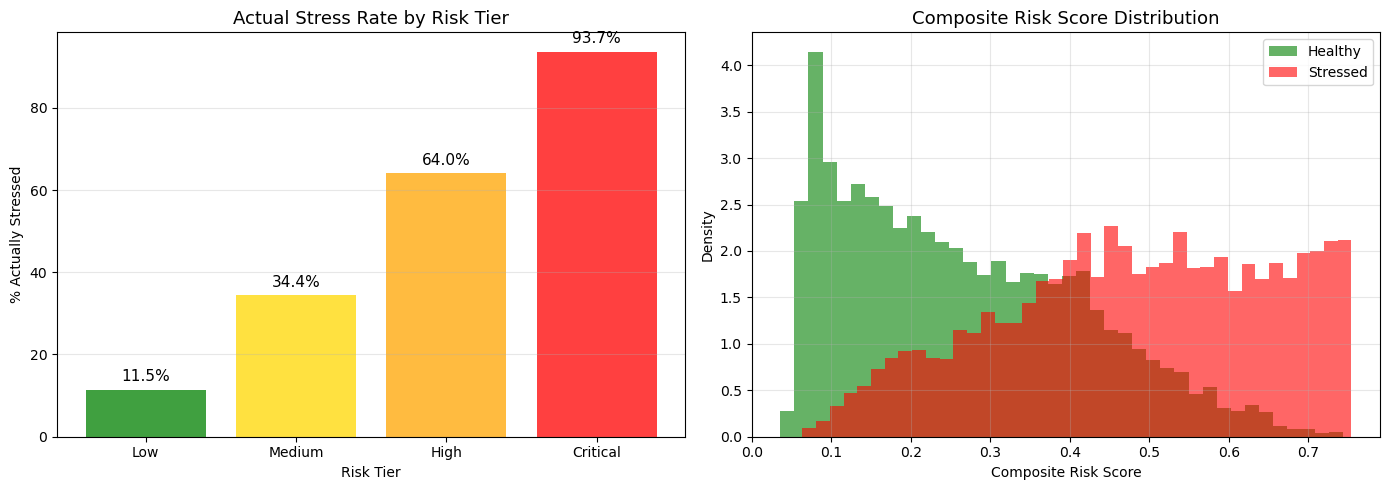


✅ Composite results saved
✅ Week 8 complete

=== FINAL MODEL SUITE ===
XGBoost AUC:         0.8211
Composite AUC:       0.8210
Conformal coverage:  90.3% (target 90%)


In [5]:
# ── ADJUST TIERS + VISUALIZE + SAVE ──────────────────────────────
# Recalibrate tier thresholds based on actual score distribution
risk_tiers = pd.cut(
    composite_score,
    bins=[0, 0.25, 0.45, 0.65, 1.01],
    labels=['Low', 'Medium', 'High', 'Critical']
)

tier_df = pd.DataFrame({'tier': risk_tiers, 'actual_stress': y_test.values})
tier_summary = tier_df.groupby('tier')['actual_stress'].agg(['mean', 'count'])

print("=== RECALIBRATED RISK TIERS ===")
print(tier_summary.round(3))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Stress rate by tier
tiers_order = ['Low', 'Medium', 'High', 'Critical']
colors = ['green', 'gold', 'orange', 'red']
means = [tier_summary.loc[t, 'mean'] if t in tier_summary.index else 0 for t in tiers_order]
axes[0].bar(tiers_order, [m*100 for m in means], color=colors, alpha=0.75)
axes[0].set_title('Actual Stress Rate by Risk Tier', fontsize=13)
axes[0].set_ylabel('% Actually Stressed')
axes[0].set_xlabel('Risk Tier')
axes[0].grid(alpha=0.3, axis='y')
for i, m in enumerate(means):
    axes[0].text(i, m*100+2, f'{m:.1%}', ha='center', fontsize=11)

# Plot 2 — Composite score distribution
axes[1].hist(composite_score[y_test==0], bins=40, alpha=0.6,
             color='green', label='Healthy', density=True)
axes[1].hist(composite_score[y_test==1], bins=40, alpha=0.6,
             color='red', label='Stressed', density=True)
axes[1].set_title('Composite Risk Score Distribution', fontsize=13)
axes[1].set_xlabel('Composite Risk Score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/composite_risk_tiers.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save everything for the dashboard/API later
results_df = pd.DataFrame({
    'xgb_prob': xgb_test_probs,
    'lstm_score': lstm_norm,
    'composite_score': composite_score,
    'risk_tier': risk_tiers,
    'actual_stress': y_test.values
})
results_df.to_csv('../data/processed/composite_results.csv', index=False)

print("\n✅ Composite results saved")
print(f"✅ Week 8 complete")
print(f"\n=== FINAL MODEL SUITE ===")
print(f"XGBoost AUC:         {xgb_test_auc:.4f}")
print(f"Composite AUC:       {composite_auc:.4f}")
print(f"Conformal coverage:  90.3% (target 90%)")